# **K-Nearest Neighbors**

In this exercise, you will build a classifier using the K-Nearest Neighbors algorithm.

---

### **1. Generating data**

You will start by generating synthetic data for this problem.  

- Generate a dataset with **n = 50 points** in a unit square. Each point should have an assigned label: orange or blue.  
  - Think about the rules to assign the labels (hint: you need a boundary rule to classify points as orange or blue).  
  - Store the x and y coordinates, along with the label, in a structured format.  
  - Vizualize the dataset.

---

### **2. The algorithm**

You will now use your generated dataset to determine the label of a new observation **(x₀, y₀)**. Here are the steps you should follow :

- Compute the distances between **(x₀, y₀)** and all points in your dataset.  
  - How will you calculate the distance ? 
  - What type of distance metric can you use ?  

- Select a value for **K**

- Identify the **K nearest neighbors** for your new point based on the distances you computed.  

- Based on the labels of the nearest neighbors, how would you decide the predicted class for the new observation ? Do it and explain your approach.

- Experiment with different values of **K** :  
  - Analyze how the prediction changes depending on different values for **K**.  
  - What happens when **K** is too small ? Too large ?

---

### **3. KNN for non linear patterns**

- Implement the K-Nearest Neighbors algorithm for datasets with non linear shapes (generate these data, you can use your creativity).  
  - What happens to your prediction as the dataset structure becomes more complex ?

- Test your implementation by generating a random test set with new points. Measure how well your algorithm performs (e.g., accuracy, precision, recall).  

- Try using a different distance metric (e.g., Manhattan distance) to see how it impacts classification. Which metric feels more appropriate for your specific problem ?

---



          x         y  label   color
0  0.374540  0.950714      1  orange
1  0.731994  0.598658      0    blue
2  0.156019  0.155995      0    blue
3  0.058084  0.866176      1  orange
4  0.601115  0.708073      1  orange


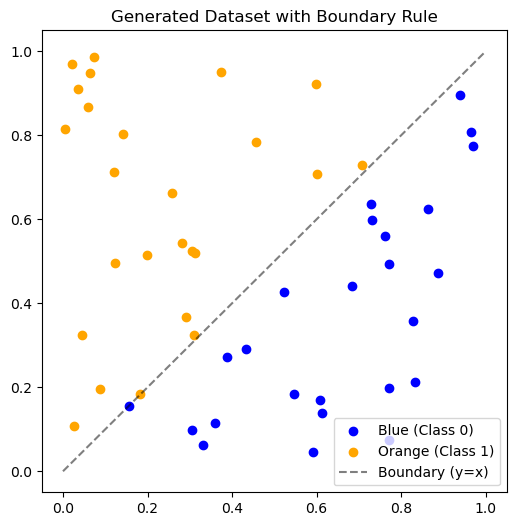

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

n_points = 50
X = np.random.rand(n_points, 2) 

labels = (X[:, 1] > X[:, 0]).astype(int)

df = pd.DataFrame({
    'x': X[:, 0], 
    'y': X[:, 1], 
    'label': labels,
    'color': ['orange' if l == 1 else 'blue' for l in labels]
})

print(df.head())

plt.figure(figsize=(6, 6))
plt.scatter(df[df['label']==0]['x'], df[df['label']==0]['y'], color='blue', label='Blue (Class 0)')
plt.scatter(df[df['label']==1]['x'], df[df['label']==1]['y'], color='orange', label='Orange (Class 1)')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Boundary (y=x)')
plt.title("Generated Dataset with Boundary Rule")
plt.legend()
plt.show()

In [4]:
from collections import Counter

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2)**2))

def predict_knn(X_train, y_train, x_new, k=3):
  
    distances = []
    
    for i in range(len(X_train)):
        dist = euclidean_distance(X_train[i], x_new)
        distances.append((dist, y_train[i]))
    
    distances.sort(key=lambda x: x[0])
    k_neighbors = distances[:k]
    
    k_labels = [label for _, label in k_neighbors]
    
    most_common = Counter(k_labels).most_common(1)
    predicted_class = most_common[0][0]
    
    return predicted_class, k_neighbors

x_new = np.array([0.6, 0.4]) 

for k_val in [1, 3, 15]:
    pred, neighbors = predict_knn(X, labels, x_new, k=k_val)
    print(f"K={k_val}: Predicted class = {'Orange' if pred==1 else 'Blue'}")


K=1: Predicted class = Blue
K=3: Predicted class = Blue
K=15: Predicted class = Blue


--- Сравнение метрик (K=5) ---
Metric          Accuracy   Precision  Recall    
---------------------------------------------
Euclidean       0.95       0.96       0.93      
Manhattan       0.95       0.96       0.93      


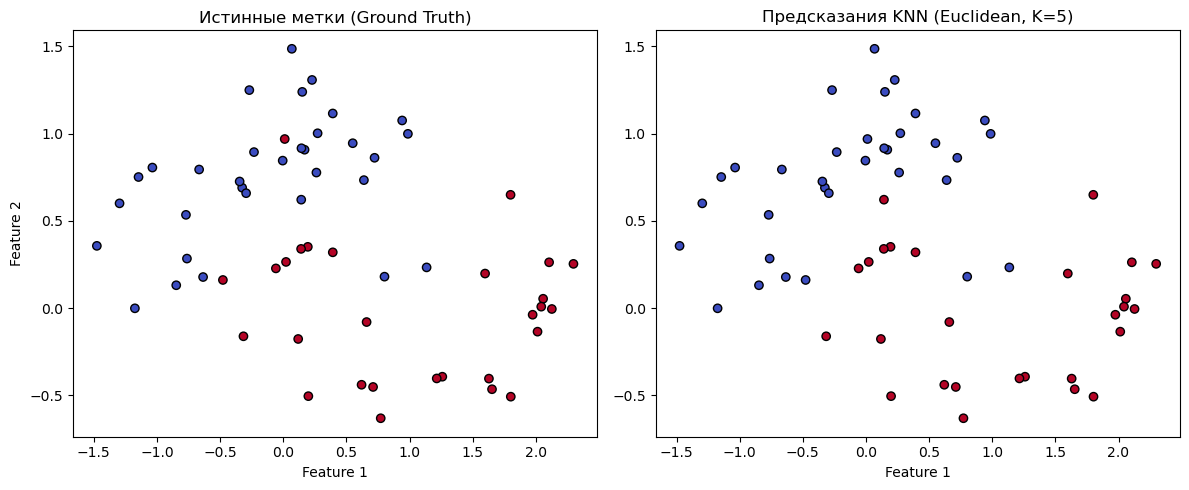

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

X_nl, y_nl = make_moons(n_samples=200, noise=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X_nl, y_nl, test_size=0.3, random_state=42)

def get_distance(p1, p2, metric='euclidean'):
    if metric == 'euclidean':
        return np.sqrt(np.sum((p1 - p2)**2))
    elif metric == 'manhattan':
        return np.sum(np.abs(p1 - p2))
    return 0

def knn_predict_batch(X_train, y_train, X_test, k=5, metric='euclidean'):
    predictions = []
    for x in X_test:
        dists = [get_distance(xt, x, metric) for xt in X_train]
        
        k_idx = np.argsort(dists)[:k]
        
        k_labels = y_train[k_idx]
        
        vote = Counter(k_labels).most_common(1)[0][0]
        predictions.append(vote)
    return predictions

k_value = 5

# 1. Euclidean Distance
y_pred_eucl = knn_predict_batch(X_train, y_train, X_test, k=k_value, metric='euclidean')
acc_eucl = accuracy_score(y_test, y_pred_eucl)
prec_eucl = precision_score(y_test, y_pred_eucl)
rec_eucl = recall_score(y_test, y_pred_eucl)

# 2. Manhattan Distance
y_pred_manh = knn_predict_batch(X_train, y_train, X_test, k=k_value, metric='manhattan')
acc_manh = accuracy_score(y_test, y_pred_manh)
prec_manh = precision_score(y_test, y_pred_manh)
rec_manh = recall_score(y_test, y_pred_manh)

print(f"--- Сравнение метрик (K={k_value}) ---")
print(f"{'Metric':<15} {'Accuracy':<10} {'Precision':<10} {'Recall':<10}")
print("-" * 45)
print(f"{'Euclidean':<15} {acc_eucl:<10.2f} {prec_eucl:<10.2f} {rec_eucl:<10.2f}")
print(f"{'Manhattan':<15} {acc_manh:<10.2f} {prec_manh:<10.2f} {rec_manh:<10.2f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolor='k')
plt.title("Истинные метки (Ground Truth)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.subplot(1, 2, 2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred_eucl, cmap='coolwarm', edgecolor='k')
plt.title(f"Предсказания KNN (Euclidean, K={k_value})")
plt.xlabel("Feature 1")

plt.tight_layout()
plt.show()


---
---

# **Support Vector Machine**

A dataset contains two classes: Class A ($y=+1$ ) and Class B ($y=-1$).

You are given six labeled data points in a 2D space:

| Point $ x_i $     | Label $ y_i $  |
|-------------------|---------------|
| $ x_1 = [2, 3] $   | $ +1 $         |
| $ x_2 = [1, 2] $   | $ +1 $         |
| $ x_3 = [3, 1] $   | $ +1 $         |
| $ x_4 = [1, 0] $   | $ -1 $         |
| $ x_5 = [2, -1] $  | $ -1 $         |
| $ x_6 = [0, 0] $   | $ -1 $         |

---

### **1. Sketch & intuition**
- **1.1:** Plot the six points on a 2D graph with $ x_1 $ -$ x_2 $  axes. Do the two classes form distinct clusters ?
- **1.2:** What does it mean for the two classes to be linearly separable ? What would this imply about the complexity of the classification problem ?
- **1.3:** Are the two classes linearly separable ? If yes, arbitrarily sketch a decision boundary (no need to optimize it yet).
- **1.4:** What is the margin in the context of a decision boundary?
- **1.5:** Why would we like to maximize the margin ? What might happen if the margin is very small ? (think about new observations and future predictions)

---

### **2. Decision Boundary for Hard-Margin**
The decision boundary for an SVM is represented as:

$$
x^T \beta + \beta_0 = 0, \quad \text{where } \beta = [\beta_1, \beta_2]^T \text{are some weights}, \text{ and } \beta_0 \text{ is the intercept.}
$$

- **2.1:** Write down the margin constraints:

$$
y_i (\beta^T x_i + \beta_0) \geq 1
$$

For each observation ($ x_1, x_2, ..., x_6 $ ), substitute $x_i$  and $y_i$  into the inequality.

- **2.2** What does the margin constraint enforce for a correctly classified point ? Explain what this constraint means for points with $y_i=+1$ and $y_i=−1$.

- **2.3** Lets say our solver choose random initial values to specify a decision boundary:
    - $\beta = [1, -1]^T$ 
    - $\beta_0 = 0$

Verify step by step, whether the margin constraint is satisfied for each observation ($x_1, x_2, \ldots, x_6$ ) given their respective labels ($y_1, y_2, \ldots, y_6$ ). Sketch the decision line.

- **2.4** At the second iteration, our solver updates the parameters : $\beta = [2, 2]^T$ & $\beta_0 = -4$. Check again the conditions for each observations and draw the line. Does the margin look to be maximized here ? Compute its lenght :  $$M = \frac{1}{||\beta||}$$,
where $ ||\beta|| = \sqrt{\beta_1^2 + \beta_2^2} $ .



- **2.5: Using sklearn (https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html), write a code to find the decision line that maximize the margin. What are the estimated parameters ? Plot the line.**
    (Hint : use the linear kernel parameter)



In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.svm import SVC
from math import sqrt

%matplotlib inline

X = np.array([
    [2,  3],   
    [1,  2],   
    [3,  1],   
    [1,  0],  
    [2, -1],   
    [0,  0]    
], dtype=float)

y = np.array([+1, +1, +1, -1, -1, -1], dtype=int)

x7 = np.array([1, 3]); y7 = +1
x8 = np.array([3, -2]); y8 = -1

In [7]:
def plot_points(X, y, ax=None, title=None, show_legend=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))
    
    ax.scatter(X[y==1,0], X[y==1,1], marker='o', s=100, label='Class +1')
   
    ax.scatter(X[y==-1,0], X[y==-1,1], marker='s', s=100, label='Class -1')
   
    for i, (xi, yi) in enumerate(zip(X, y), start=1):
        ax.annotate(f"x{i}", (xi[0]+0.08, xi[1]+0.08))
    ax.axhline(0, color='gray', linewidth=0.6)
    ax.axvline(0, color='gray', linewidth=0.6)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    if title:
        ax.set_title(title)
    if show_legend:
        ax.legend()
    ax.set_aspect('equal', 'box')
    return ax

def plot_line_from_beta(beta, beta0, ax=None, xlim=(-1,4), linestyle='-', label=None):
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))
    xs = np.linspace(xlim[0], xlim[1], 200)
    b1, b2 = beta[0], beta[1]
    if abs(b2) > 1e-8:
        ys = -(b1*xs + beta0) / b2
        ax.plot(xs, ys, linestyle, linewidth=2, label=label)
    else:
        x_vert = -beta0 / b1
        ax.axvline(x_vert, linestyle=linestyle, linewidth=2, label=label)
    return ax


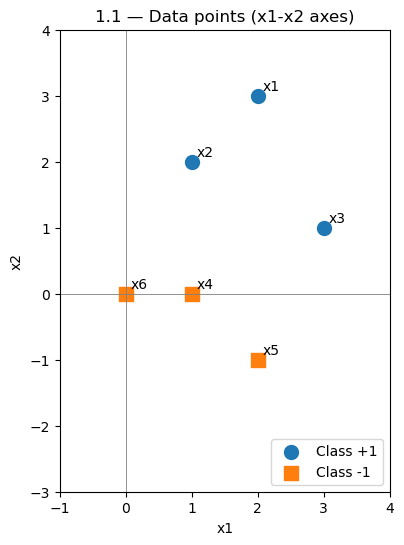

In [8]:
ax = plot_points(X, y, title="1.1 — Data points (x1-x2 axes)")
ax.set_xlim(-1, 4)
ax.set_ylim(-3, 4)
plt.show()

1.1 (plot): The three +1 points live roughly in the upper-right region: [2,3], [1,2], [3,1]. The -1 points are lower/left-ish: [1,0], [2,-1], [0,0]. They form two groups that look separable by a straight line.

1.2 (linear separability): Two classes are linearly separable if you can draw a straight line (in 2D) that places all +1 points on one side and all -1 points on the other, with no misclassifications. If separable, the classification problem is simpler: SVM can find a separating hyperplane with margin > 0 and no slack needed (hard-margin).

1.3 (are they separable?): Visually yes — you can draw a line separating the sets. Any such line is a candidate decision boundary.

1.4 (margin): Margin = distance from the decision boundary to the nearest points (support vectors). For an SVM normalized so constraints are 

$$
y_i (\beta^T x_i + \beta_0) \geq 1
$$

, the geometric margin equals 
$$M = \frac{1}{||\beta||}$$

1.5 (why maximize margin?): Maximizing the margin tends to give better generalization to unseen data — a larger margin makes the classifier more robust to noise and small perturbations. If the margin is very small, the classifier is more sensitive; small changes or new data may flip class predictions (overfitting risk).

In [9]:
def eval_constraints(beta, beta0, X, y):
    values = []
    for i, (xi, yi) in enumerate(zip(X, y), start=1):
        score = float(np.dot(beta, xi) + beta0)
        constraint_value = yi * score
        values.append((i, xi, yi, score, constraint_value))
    return values
def print_constraints(values):
    print("i   x_i        y_i    score    y_i * score   constraint OK?")
    print("-------------------------------------------------------------")
    for i, xi, yi, score, c in values:
        holds = c >= 1 - 1e-9  # tiny tolerance
        print(f"{i}   {xi.tolist()}   {yi:+d}    {score:8.3f}    {c:8.3f}      {holds}")

Checking constraints for beta = [1, -1], beta0 = 0
i   x_i        y_i    score    y_i * score   constraint OK?
-------------------------------------------------------------
1   [2.0, 3.0]   +1      -1.000      -1.000      False
2   [1.0, 2.0]   +1      -1.000      -1.000      False
3   [3.0, 1.0]   +1       2.000       2.000      True
4   [1.0, 0.0]   -1       1.000      -1.000      False
5   [2.0, -1.0]   -1       3.000      -3.000      False
6   [0.0, 0.0]   -1       0.000      -0.000      False


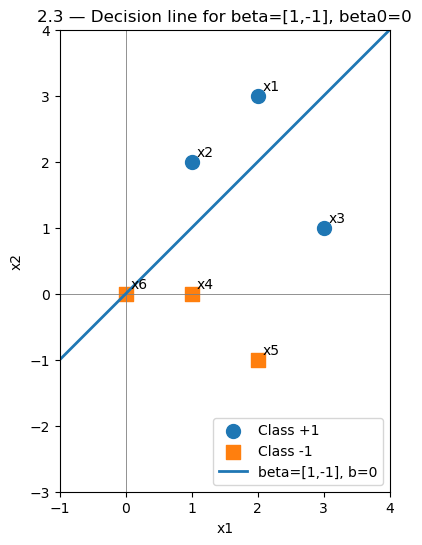

In [10]:
beta_a = np.array([1.0, -1.0])
beta0_a = 0.0
vals_a = eval_constraints(beta_a, beta0_a, X, y)
print("Checking constraints for beta = [1, -1], beta0 = 0")
print_constraints(vals_a)

ax = plot_points(X, y, title="2.3 — Decision line for beta=[1,-1], beta0=0")
plot_line_from_beta(beta_a, beta0_a, ax=ax, label='beta=[1,-1], b=0')
ax.set_xlim(-1,4)
ax.set_ylim(-3,4)
ax.legend()
plt.show()


Checking constraints for beta = [2, 2], beta0 = -4
i   x_i        y_i    score    y_i * score   constraint OK?
-------------------------------------------------------------
1   [2.0, 3.0]   +1       6.000       6.000      True
2   [1.0, 2.0]   +1       2.000       2.000      True
3   [3.0, 1.0]   +1       4.000       4.000      True
4   [1.0, 0.0]   -1      -2.000       2.000      True
5   [2.0, -1.0]   -1      -2.000       2.000      True
6   [0.0, 0.0]   -1      -4.000       4.000      True

||beta|| = 2.828427, Margin M = 1/||beta|| = 0.353553


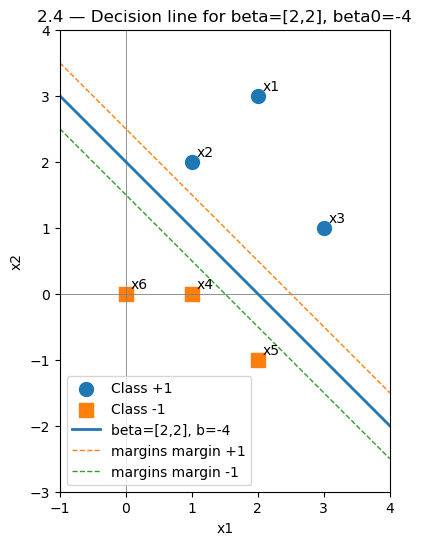

In [11]:
beta_b = np.array([2.0, 2.0])
beta0_b = -4.0
vals_b = eval_constraints(beta_b, beta0_b, X, y)

print("Checking constraints for beta = [2, 2], beta0 = -4")
print_constraints(vals_b)

norm_beta_b = np.linalg.norm(beta_b)
M_b = 1.0 / norm_beta_b
print(f"\n||beta|| = {norm_beta_b:.6f}, Margin M = 1/||beta|| = {M_b:.6f}")

# plot
ax = plot_points(X, y, title="2.4 — Decision line for beta=[2,2], beta0=-4")
plot_line_from_beta(beta_b, beta0_b, ax=ax, label='beta=[2,2], b=-4')
def plot_margin_lines(beta, beta0, ax, linestyle='--', label_prefix=""):
    b1,b2 = beta[0], beta[1]
    xs = np.linspace(-1,4,200)
    if abs(b2) > 1e-8:
        ys_plus = -(b1*xs + beta0 - 1)/b2  # beta^T x + beta0 = 1 -> y = -(b1 x + beta0 - 1)/b2
        ys_minus = -(b1*xs + beta0 + 1)/b2 # beta^T x + beta0 = -1
        ax.plot(xs, ys_plus, linestyle, linewidth=1, label=label_prefix + ' margin +1')
        ax.plot(xs, ys_minus, linestyle, linewidth=1, label=label_prefix + ' margin -1')
    else:
        x_plus = -(beta0 - 1)/b1
        x_minus = -(beta0 + 1)/b1
        ax.axvline(x_plus, linestyle=linestyle)
        ax.axvline(x_minus, linestyle=linestyle)

plot_margin_lines(beta_b, beta0_b, ax, linestyle='--', label_prefix="margins")
ax.set_xlim(-1,4)
ax.set_ylim(-3,4)
ax.legend()
plt.show()


SVC (linear) solution with large C:
beta (coef_) = [0.49984 0.99968]
beta0 (intercept_) = -1.4994133333333337
||beta|| = 1.117676217873495
Margin (M = 1/||beta||) = 0.8947134993196981


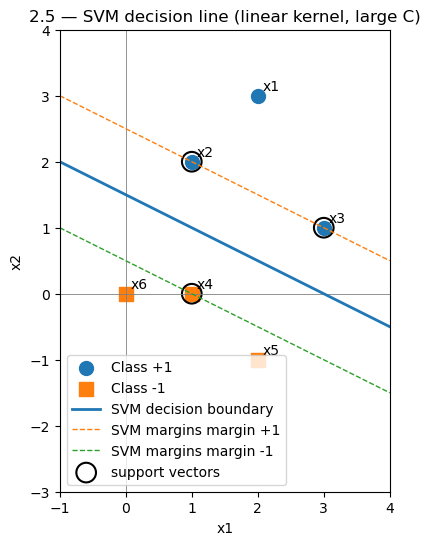

In [12]:
svc_hard = SVC(kernel='linear', C=1e6)  
svc_hard.fit(X, y)

coef = svc_hard.coef_.ravel()  # beta
intercept = svc_hard.intercept_[0]  # beta0
print("SVC (linear) solution with large C:")
print("beta (coef_) =", coef)
print("beta0 (intercept_) =", intercept)
print("||beta|| =", np.linalg.norm(coef))
print("Margin (M = 1/||beta||) =", 1.0/np.linalg.norm(coef))

ax = plot_points(X, y, title="2.5 — SVM decision line (linear kernel, large C)")
plot_line_from_beta(coef, intercept, ax=ax, label='SVM decision boundary')
plot_margin_lines(coef, intercept, ax, linestyle='--', label_prefix='SVM margins')
# Plot support vectors
sv = svc_hard.support_vectors_
ax.scatter(sv[:,0], sv[:,1], s=200, facecolors='none', edgecolors='k', linewidths=1.5, label='support vectors')
ax.set_xlim(-1,4)
ax.set_ylim(-3,4)
ax.legend()
plt.show()



---

### **3. Slack Variables for a Soft-Margin**
In real-world datasets, perfect separation might not be possible as the data might be mixed. 

Lets add two new observations : 
- $ x_7 = [1, 3] $  with $y_7 = +1 $
- $ x_8 = [3, -2] $  with $y_8 = -1 $


Slack variables ($ \xi_i $ ) can be added to relax the SVM constraint for incorrectly classified or margin-violating points:

$$ y_i (\beta^T x_i + \beta_0) \geq 1 - \xi_i, \quad \xi_i \geq 0 $$


They are computed by the Hinge Loss function:

$$
\xi_i = \max(0, 1 - y_i (\beta^T x_i + \beta_0))
$$

- **3.1: Check for each observation if the point violates the soft-margin constraint. Compute the slack variable $ \xi_i $  for each point.**


- **3.2: What is the slack variable when the observation is well classified ?**

- **3.3: Identify the points that violate the margin.**

- **3.3: Compute the total violation:**

$$
\text{Total Slack:} \quad \sum_{i=1}^n \xi_i.
$$

---

### **4. Adding Slack Variables to the Objective Function**

The objective function that we used for the hard margin can be modified to include the penalty term for the slack variables. By doing so, our final problem is :

$$
 \text{minimize} \quad \frac{1}{2} \|\beta\|^2 + C \sum_{i=1}^{n} \xi_i 
$$

subject to :

$$
 y_i (\beta \cdot x_i + b) \geq 1 - \xi_i \quad \forall i 
$$



$$ \xi_i \geq 0 \quad \forall i $$

Where, 

1. $ \frac{1}{2} \|\beta\|^2 $ encourages a large margin by minimizing the norm of the weight vector.
2. $C \sum_{i=1}^{n} \xi_i$ penalizes the slack variables. $C$  is a regularization parameter that controls the trade-off between maximizing the margin and minimizing the classification error.
3. $ y_i (\beta \cdot x_i + b) \geq 1 - \xi_i $ : This constraint allows for some points to be within the margin or misclassified, thanks to the slack variable.
4. $ \xi_i \geq 0 $ : Ensures that slack variables are non-negative.

By adding slack variables to the objective function, the soft margin SVM can handle non-separable data more effectively, balancing the need for a large margin with the practical reality of misclassifications.

- **4. How does increasing or decreasing C affect the trade-off between maximizing the margin and minimizing classification errors ?**

---


In [13]:
X_soft = np.vstack([X, x7, x8])
y_soft = np.hstack([y, y7, y8])

def compute_slacks(beta, beta0, X, y):
    slacks = []
    for i, (xi, yi) in enumerate(zip(X, y), start=1):
        score = float(np.dot(beta, xi) + beta0)
        xi_val = max(0.0, 1.0 - yi * score)
        slacks.append((i, xi, yi, score, xi_val))
    return slacks

slacks_svm = compute_slacks(coef, intercept, X_soft, y_soft)

print("Slacks (xi_i) for each observation using the SVM solution above:")
print("i   x_i       y_i   beta^T x_i + b    xi_i")

total_slack = 0.0
for i, xi, yi, score, xi_val in slacks_svm:
    print(f"{i}  {xi.tolist()}   {yi:+d}    {score:8.3f}        {xi_val:6.5f}")
    total_slack += xi_val

print(f"\nTotal Slack (sum xi_i) = {total_slack:.6f}")



Slacks (xi_i) for each observation using the SVM solution above:
i   x_i       y_i   beta^T x_i + b    xi_i
1  [2.0, 3.0]   +1       2.499        0.00000
2  [1.0, 2.0]   +1       1.000        0.00021
3  [3.0, 1.0]   +1       1.000        0.00021
4  [1.0, 0.0]   -1      -1.000        0.00043
5  [2.0, -1.0]   -1      -1.499        0.00000
6  [0.0, 0.0]   -1      -1.499        0.00000
7  [1.0, 3.0]   +1       1.999        0.00000
8  [3.0, -2.0]   -1      -1.999        0.00000

Total Slack (sum xi_i) = 0.000853


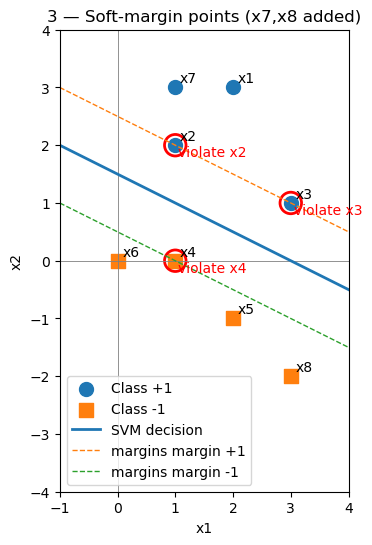

In [14]:
ax = plot_points(X_soft, y_soft, title="3 — Soft-margin points (x7,x8 added)")
plot_line_from_beta(coef, intercept, ax=ax, label='SVM decision')
plot_margin_lines(coef, intercept, ax, linestyle='--', label_prefix='margins')
# annotate slack-violating points
for i, xi, yi, score, xi_val in slacks_svm:
    if xi_val > 1e-9:
        ax.scatter([xi[0]], [xi[1]], s=240, facecolors='none', edgecolors='red', linewidths=2)
        ax.annotate(f'violate x{i}', (xi[0]+0.05, xi[1]-0.2), color='red')
ax.set_xlim(-1,4)
ax.set_ylim(-4,4)
ax.legend()
plt.show()

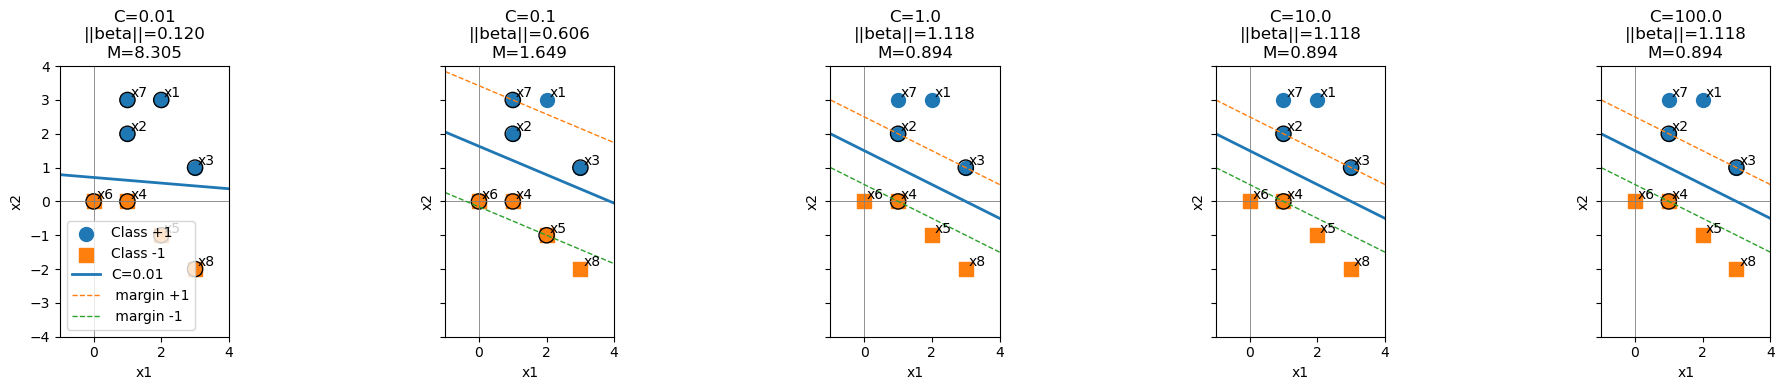

In [15]:
Cs = [0.01, 0.1, 1.0, 10.0, 100.0]
models = {}
fig, axes = plt.subplots(1, len(Cs), figsize=(4*len(Cs), 4), sharey=True)
for ax, C in zip(axes, Cs):
    model = SVC(kernel='linear', C=C)
    model.fit(X_soft, y_soft)
    models[C] = model
    coef_c = model.coef_.ravel()
    intercept_c = model.intercept_[0]
    plot_points(X_soft, y_soft, ax=ax, show_legend=False)
    plot_line_from_beta(coef_c, intercept_c, ax=ax, label=f'C={C}')
    plot_margin_lines(coef_c, intercept_c, ax=ax, linestyle='--')
    sv = model.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=120, facecolors='none', edgecolors='k')
    ax.set_title(f"C={C}\n||beta||={np.linalg.norm(coef_c):.3f}\nM={1/np.linalg.norm(coef_c):.3f}")
    ax.set_xlim(-1,4)
    ax.set_ylim(-4,4)

axes[0].legend()
plt.tight_layout()
plt.show()
